In [13]:
# 1) Design model (input, output, forward pass with different layers)
# 2) Construct loss and optimizer
# 3) Training loop
#       - Forward = compute prediction and loss
#       - Backward = compute gradients
#       - Update weights

import torch
import torch.nn as nn

# Linear regression
# f = w * x

# here : f = 2 * x

# 0) Training samples, watch the shape!
X = torch.tensor([[1], [2], [3], [4]], dtype=torch.float32)
Y = torch.tensor([[2], [4], [6], [8]], dtype=torch.float32)

n_samples, n_features = X.shape
print(f'#samples: {n_samples}, #features: {n_features}')
# 0) create a test sample
X_test = torch.tensor([5], dtype=torch.float32)

# 1) Design Model, the model has to implement the forward pass!
# Here we can use a built-in model from PyTorch
input_size = n_features
output_size = n_features

# we can call this model with samples X
model = nn.Linear(input_size, output_size)

'''
class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegression, self).__init__()
        # define diferent layers
        self.lin = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.lin(x)

model = LinearRegression(input_size, output_size)
'''

print(f'Prediction before training: f(5) = {model(X_test).item():.3f}')

# 2) Define loss and optimizer
learning_rate = 0.01
n_iters = 100  # 500 or 1000으로

loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# 3) Training loop
for epoch in range(n_iters):
    # predict = forward pass with our model
    y_predicted = model(X)

    # loss
    l = loss(Y, y_predicted)

    # calculate gradients = backward pass
    l.backward()

    # update weights
    optimizer.step()

    # zero the gradients after updating
    optimizer.zero_grad()

    if epoch % 10 == 0:
        [w, b] = model.parameters() # unpack parameters
        print('epoch ', epoch+1, ': w = ', w[0][0].item(), ' loss = ', l)

print(f'Prediction after training: f(5) = {model(X_test).item():.3f}')

#samples: 4, #features: 1
Prediction before training: f(5) = 0.452
epoch  1 : w =  0.22802239656448364  loss =  tensor(24.9048, grad_fn=<MseLossBackward0>)
epoch  11 : w =  1.3774141073226929  loss =  tensor(0.8756, grad_fn=<MseLossBackward0>)
epoch  21 : w =  1.5722639560699463  loss =  tensor(0.2405, grad_fn=<MseLossBackward0>)
epoch  31 : w =  1.6132820844650269  loss =  tensor(0.2113, grad_fn=<MseLossBackward0>)
epoch  41 : w =  1.6292706727981567  loss =  tensor(0.1987, grad_fn=<MseLossBackward0>)
epoch  51 : w =  1.640955924987793  loss =  tensor(0.1871, grad_fn=<MseLossBackward0>)
epoch  61 : w =  1.6516797542572021  loss =  tensor(0.1762, grad_fn=<MseLossBackward0>)
epoch  71 : w =  1.6619879007339478  loss =  tensor(0.1659, grad_fn=<MseLossBackward0>)
epoch  81 : w =  1.6719753742218018  loss =  tensor(0.1563, grad_fn=<MseLossBackward0>)
epoch  91 : w =  1.681665301322937  loss =  tensor(0.1472, grad_fn=<MseLossBackward0>)
Prediction after training: f(5) = 9.362


In [14]:
y_predicted

tensor([[2.6030],
        [4.2922],
        [5.9814],
        [7.6706]], grad_fn=<AddmmBackward0>)

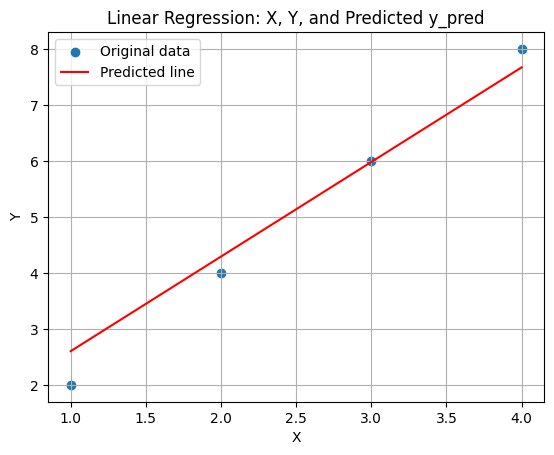

In [15]:
import matplotlib.pyplot as plt

plt.scatter(X.numpy(), Y.numpy(), label='Original data')
plt.plot(X.numpy(), y_predicted.detach().numpy(), color='red', label='Predicted line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression: X, Y, and Predicted y_pred')
plt.legend()
plt.grid(True)
plt.show()

06_1_loss_and_optimizer.ipynb 코드보다 이 코드가 "정확성이 떨어진다"기보다는, "편향(bias)이라는 변수가 하나 더 추가되었고 랜덤 초기화 방식 때문에 100번의 학습으로는 충분히 수렴하지 못했다"고 판단

해결 방법:

- n_iters를 500~1000 정도로 늘린다.

- nn.Linear(input_size, output_size, bias=False)로 설정하여 첫 번째 코드와 똑같은 조건(y=w⋅x)으로 만들기